## Завдання 1
Потрібно проаналізувати взаємозв'язок між користувачами, сесіями та виручкою за днями. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
 * Сформуйте таблицю мінімум на 30 днів із колонками "date", "users", "sessions", "revenue".
 * Розрахуйте кореляційну матрицю для цих метрик.
 * Побудуйте діаграми розсіювання для пар: users-sessions, users-revenue, sessions-revenue.
 * Побудуйте лінійний графік "revenue" за датами.
 * Виведіть матрицю та всі графіки.



Кореляційна матриця:
             users  sessions   revenue
users     1.000000  0.895046  0.748096
sessions  0.895046  1.000000  0.752914
revenue   0.748096  0.752914  1.000000


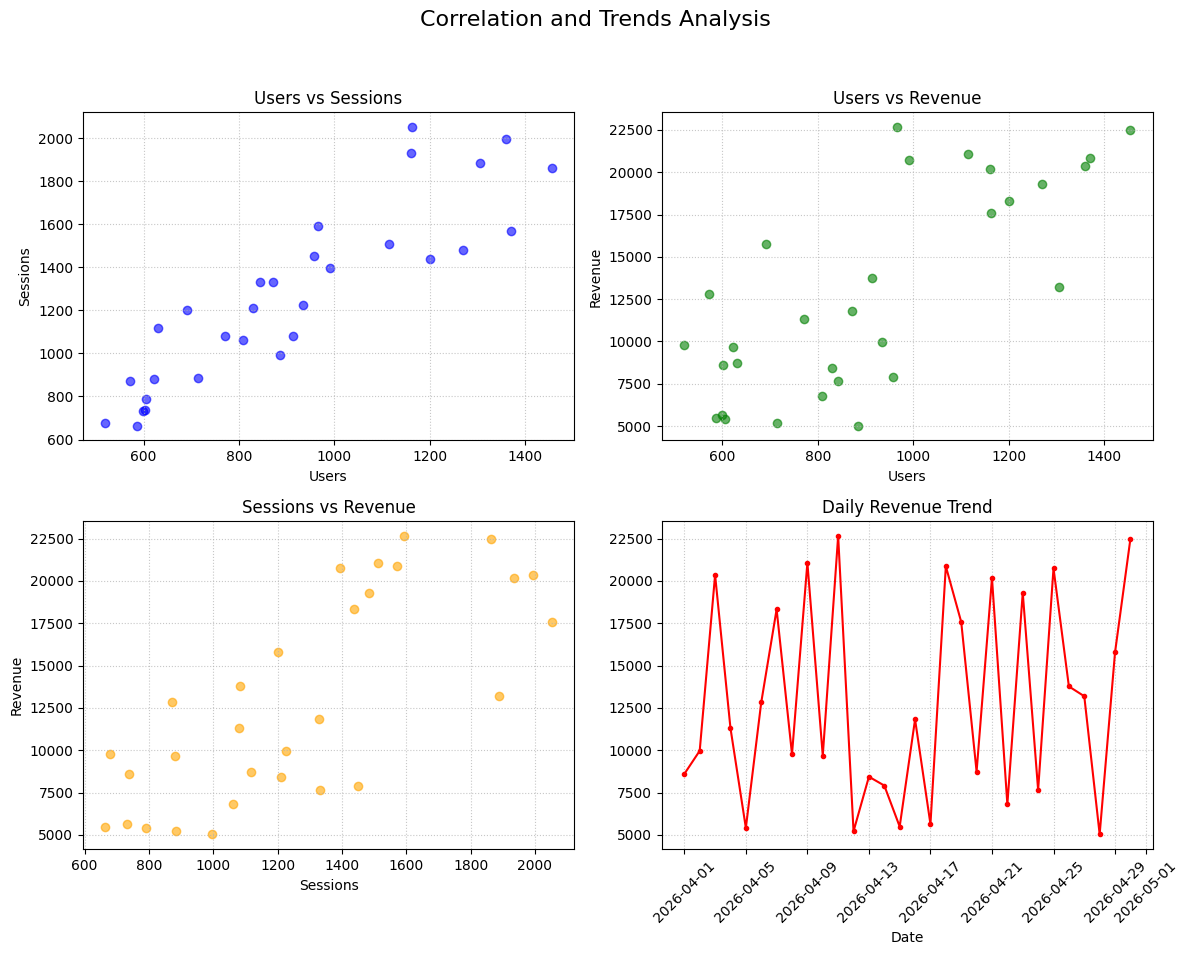

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
dates = pd.date_range(start='2026-04-01', periods=30)
users = np.random.randint(500, 1500, size=30)
sessions = users * np.random.uniform(1.1, 1.8, size=30)
revenue = sessions * np.random.uniform(5, 15, size=30)

df = pd.DataFrame({
    'date': dates,
    'users': users,
    'sessions': sessions,
    'revenue': revenue
})

corr_matrix = df[['users', 'sessions', 'revenue']].corr()
print("Кореляційна матриця:")
print(corr_matrix)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].scatter(df['users'], df['sessions'], color='blue', alpha=0.6)
axs[0, 0].set_title('Users vs Sessions')
axs[0, 0].set_xlabel('Users')
axs[0, 0].set_ylabel('Sessions')

axs[0, 1].scatter(df['users'], df['revenue'], color='green', alpha=0.6)
axs[0, 1].set_title('Users vs Revenue')
axs[0, 1].set_xlabel('Users')
axs[0, 1].set_ylabel('Revenue')

axs[1, 0].scatter(df['sessions'], df['revenue'], color='orange', alpha=0.6)
axs[1, 0].set_title('Sessions vs Revenue')
axs[1, 0].set_xlabel('Sessions')
axs[1, 0].set_ylabel('Revenue')

axs[1, 1].plot(df['date'], df['revenue'], color='red', marker='.')
axs[1, 1].set_title('Daily Revenue Trend')
axs[1, 1].set_xlabel('Date')
axs[1, 1].tick_params(axis='x', rotation=45)

for ax in axs.flat:
    ax.grid(True, linestyle=':', alpha=0.7)

fig.suptitle('Correlation and Trends Analysis', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

## Завдання 2
Потрібно проаналізувати дані A/B-експерименту та візуалізувати конверсії. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
 * Сформуйте таблицю з полями "group" (A або B) і "converted" (0/1) з не менш ніж 100 спостереженнями в кожній групі.
 * Розрахуйте конверсію в групах, абсолютну різницю та відносну зміну.
 * Побудуйте 95% довірчі інтервали для конверсії в кожній групі.
 * Побудуйте стовпчасту діаграму конверсій груп із відображенням довірчих інтервалів.
 * Виведіть усі розраховані значення та графік.



Конверсія A: 12.00%
Конверсія B: 19.33%
Абсолютна різниця: 7.33%
Відносна зміна: 61.11%


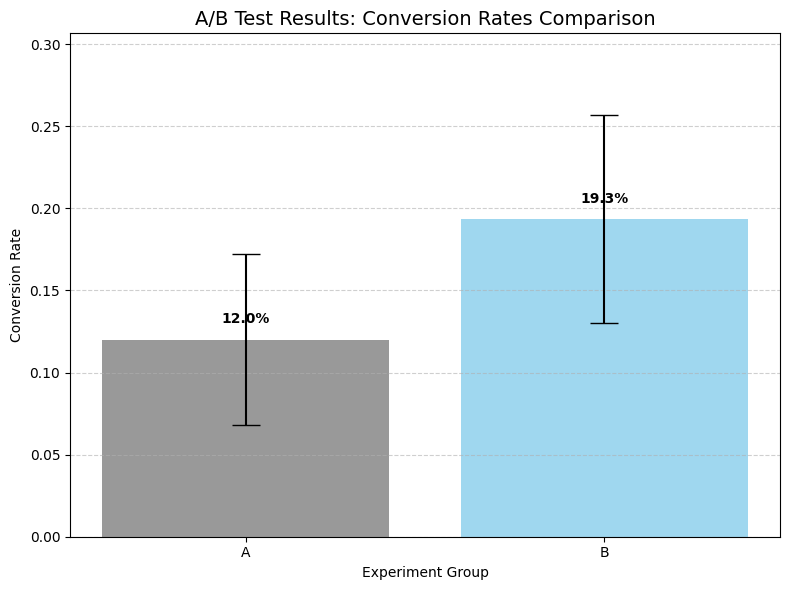

In [2]:
np.random.seed(42)
n_samples = 150 # не менше 100 на групу

group_a = np.random.choice([0, 1], size=n_samples, p=[0.88, 0.12])
group_b = np.random.choice([0, 1], size=n_samples, p=[0.82, 0.18])

df = pd.DataFrame({
    'group': ['A'] * n_samples + ['B'] * n_samples,
    'converted': np.concatenate([group_a, group_b])
})

stats = df.groupby('group')['converted'].agg(['count', 'sum', 'mean'])
stats.columns = ['n', 'successes', 'conversion_rate']

conv_a = stats.loc['A', 'conversion_rate']
conv_b = stats.loc['B', 'conversion_rate']

abs_diff = conv_b - conv_a
rel_change = (conv_b / conv_a - 1) * 100

def get_ci_error(cr, n):
    return 1.96 * np.sqrt((cr * (1 - cr)) / n)

stats['ci_error'] = stats.apply(lambda row: get_ci_error(row['conversion_rate'], row['n']), axis=1)

print(f"Конверсія A: {conv_a:.2%}")
print(f"Конверсія B: {conv_b:.2%}")
print(f"Абсолютна різниця: {abs_diff:.2%}")
print(f"Відносна зміна: {rel_change:.2f}%")

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(stats.index, stats['conversion_rate'], 
       yerr=stats['ci_error'], 
       capsize=10, 
       color=['gray', 'skyblue'], 
       alpha=0.8,
       label='Conversion Rate with 95% CI')

ax.set_title('A/B Test Results: Conversion Rates Comparison', fontsize=14)
ax.set_ylabel('Conversion Rate')
ax.set_xlabel('Experiment Group')
ax.set_ylim(0, max(stats['conversion_rate'] + stats['ci_error']) + 0.05)

for i, rate in enumerate(stats['conversion_rate']):
    ax.text(i, rate + 0.01, f"{rate:.1%}", ha='center', fontweight='bold')

ax.grid(axis='y', linestyle='--', alpha=0.6)
fig.tight_layout()

plt.show()

## Завдання 3
Потрібно перевірити дію центральної граничної теореми на прикладі несиметричного розподілу. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
 * Згенеруйте генеральну сукупність щонайменше з 50 000 спостережень із несиметричного розподілу.
 * Сформуйте кілька підвибірок фіксованого розміру n і для кожної обчисліть середнє.
 * Збережіть вибіркові середні та побудуйте їхню гістограму.
 * Повторіть процедуру для щонайменше двох різних n і виведіть обидві гістограми.
 * Виведіть середнє і стандартне відхилення вибіркових середніх для кожного n.



Генеральне середнє: 1.9919
------------------------------
Для n=5: Середнє = 2.0166, Станд. відхилення = 0.8727
Для n=50: Середнє = 1.9958, Станд. відхилення = 0.2828


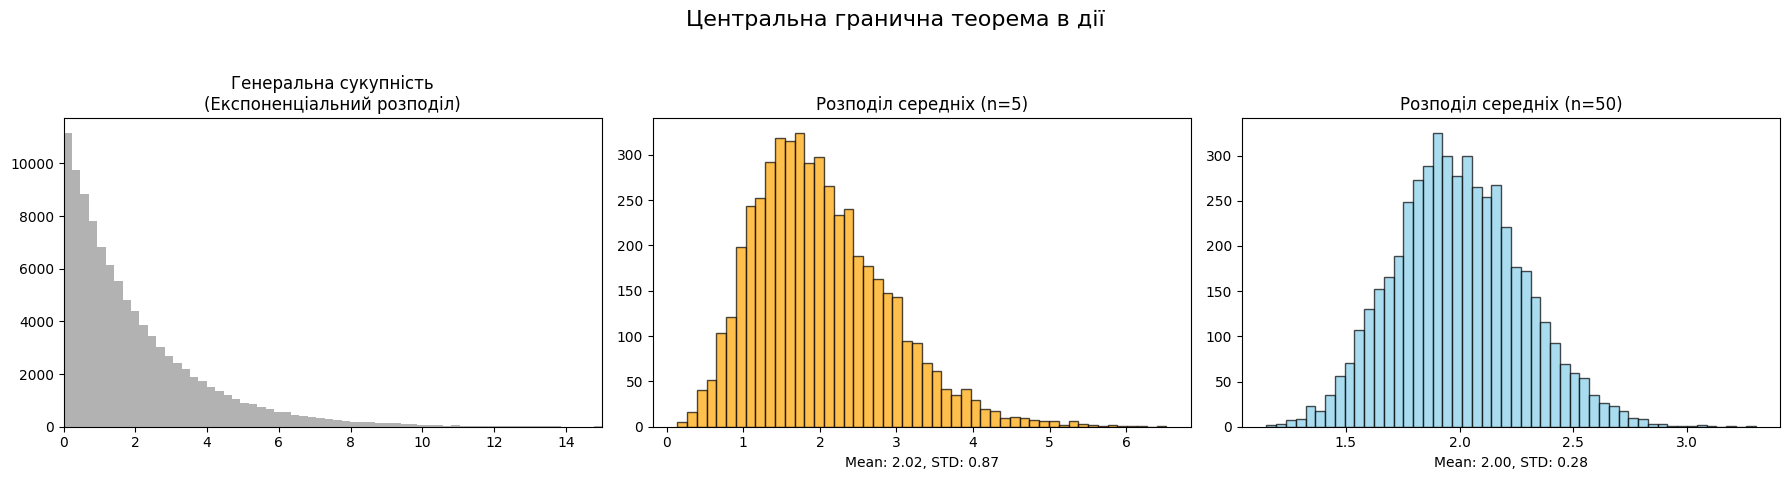

In [3]:
np.random.seed(42)
population_size = 100000
population = np.random.exponential(scale=2, size=population_size)

def get_sample_means(pop, n, num_samples=5000):
    sample_means = []
    for _ in range(num_samples):
        sample = np.random.choice(pop, size=n)
        sample_means.append(np.mean(sample))
    return np.array(sample_means)

n_small = 5
n_large = 50

means_small = get_sample_means(population, n_small)
means_large = get_sample_means(population, n_large)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].hist(population, bins=100, color='gray', alpha=0.6)
axs[0].set_title(f'Генеральна сукупність\n(Експоненціальний розподіл)')
axs[0].set_xlim(0, 15)

axs[1].hist(means_small, bins=50, color='orange', edgecolor='black', alpha=0.7)
axs[1].set_title(f'Розподіл середніх (n={n_small})')
axs[1].set_xlabel(f'Mean: {np.mean(means_small):.2f}, STD: {np.std(means_small):.2f}')

axs[2].hist(means_large, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axs[2].set_title(f'Розподіл середніх (n={n_large})')
axs[2].set_xlabel(f'Mean: {np.mean(means_large):.2f}, STD: {np.std(means_large):.2f}')

print(f"Генеральне середнє: {np.mean(population):.4f}")
print("-" * 30)
print(f"Для n={n_small}: Середнє = {np.mean(means_small):.4f}, Станд. відхилення = {np.std(means_small):.4f}")
print(f"Для n={n_large}: Середнє = {np.mean(means_large):.4f}, Станд. відхилення = {np.std(means_large):.4f}")

fig.suptitle('Центральна гранична теорема в дії', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Завдання 4
Потрібно проаналізувати часовий ряд продажів і візуалізувати ковзаючі метрики. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
 * Сформуйте таблицю "date" і "sales" за 90 днів.
 * Додайте ковзне середнє і ковзне стандартне відхилення за обраним вікном.
 * Побудуйте графік вихідних продажів і графік ковзного середнього на одному полі.
 * Побудуйте окремий графік ковзного стандартного відхилення.
 * Виведіть таблицю з першими рядками нових стовпців і обидва графіки.



Перші рядки з розрахованими метриками (вікно 7 днів):
         date       sales  rolling_mean  rolling_std
6  2026-01-07  130.429765    111.170981    12.547532
7  2026-01-08  119.376689    112.874692    12.765959
8  2026-01-09  101.946648    113.288552    12.280806
9  2026-01-10  118.250760    114.186872    12.397079
10 2026-01-11  104.284690    111.053794    11.595688
11 2026-01-12  105.373604    111.681154    11.066691


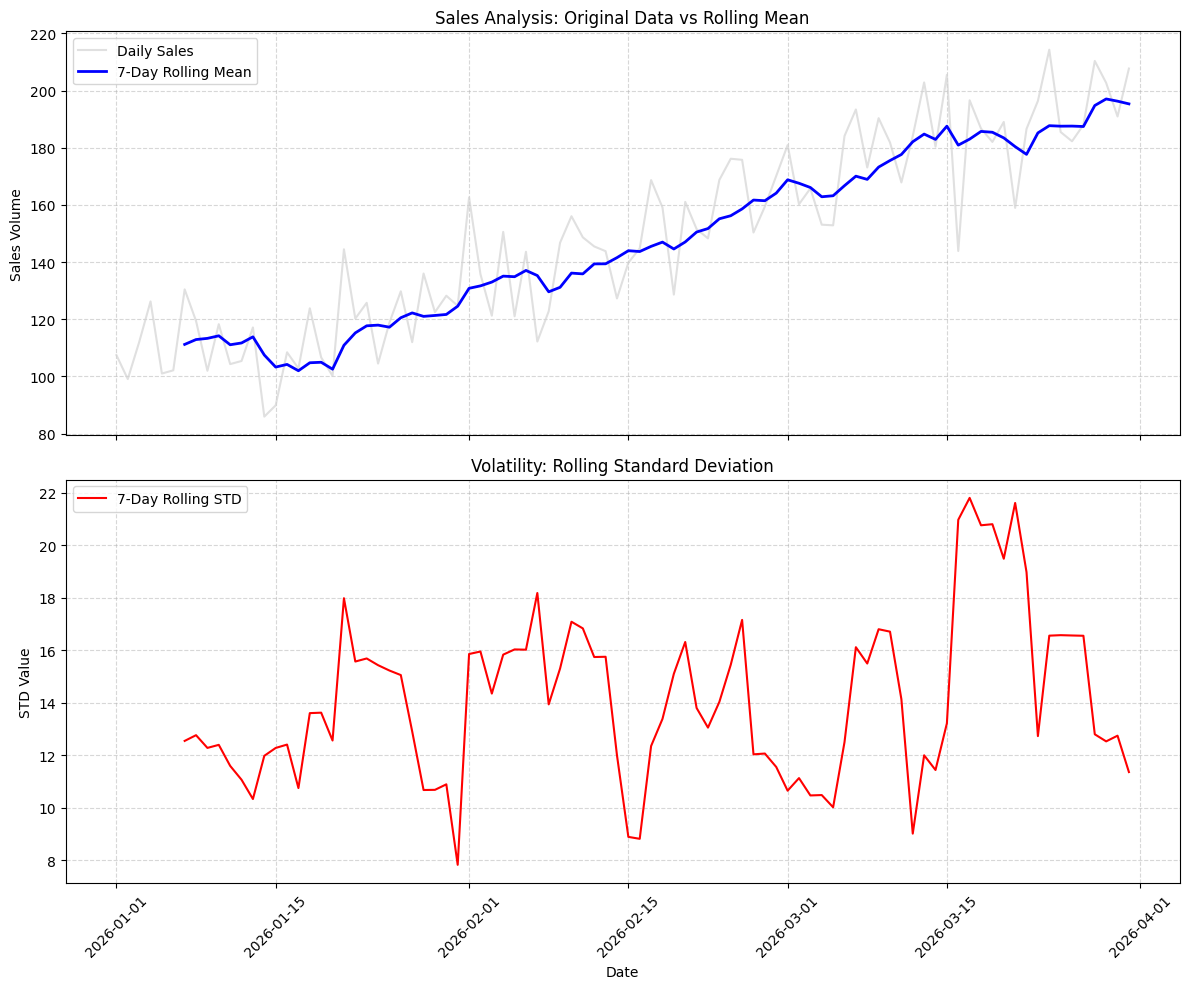

In [4]:
np.random.seed(42)
dates = pd.date_range(start='2026-01-01', periods=90)
sales = np.linspace(100, 200, 90) + np.random.normal(0, 15, 90)

df = pd.DataFrame({'date': dates, 'sales': sales})

window = 7
df['rolling_mean'] = df['sales'].rolling(window=window).mean()
df['rolling_std'] = df['sales'].rolling(window=window).std()

print(f"Перші рядки з розрахованими метриками (вікно {window} днів):")
print(df.iloc[window-1:window+5])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(df['date'], df['sales'], color='lightgray', alpha=0.7, label='Daily Sales')
ax1.plot(df['date'], df['rolling_mean'], color='blue', linewidth=2, label=f'{window}-Day Rolling Mean')
ax1.set_title('Sales Analysis: Original Data vs Rolling Mean')
ax1.set_ylabel('Sales Volume')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(df['date'], df['rolling_std'], color='red', linewidth=1.5, label=f'{window}-Day Rolling STD')
ax2.set_title('Volatility: Rolling Standard Deviation')
ax2.set_ylabel('STD Value')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.xticks(rotation=45)

fig.tight_layout()
plt.show()